# Урок 15.3. Пределы: подходим всё ближе

**Интерактивная версия:** `lessons/lesson_15_3/web/index.html`

**После урока вы сможете:** задавать последовательности и описывать их поведение, доказывать пределы
по ε–N и ε–δ, находить пределы геометрической прогрессии, итераций и рядов, отличать предел от значения,
находить односторонние пределы и пределы на бесконечности, асимптоты — и видеть пределы в бустинге,
log-loss, законе больших чисел и ошибках округления.

Блоки урока:

1. **Последовательности:** способы задать, поведение, коридор ε и номер $N$, доказательства, $q^n$,
   скорость сходимости, монотонная и ограниченная, итерации, ряды.
2. **Предел функции в точке:** таблица, график, алгебра, ловушки; предел и значение; по Гейне;
   односторонние пределы; когда предела нет.
3. **Бесконечность:** бесконечные пределы, пределы на бесконечности, асимптоты.
4. **Строгость:** ε–δ численно и по формулам, отрицание.
5. **Пределы в анализе и ML:** производная, бустинг, сигмоида и log-loss, закон больших чисел, округление.

In [1]:
import sys
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "shared" / "python" / "gbcourse").is_dir())
sys.path.insert(0, str(ROOT / "shared" / "python"))

import math
from decimal import Decimal, getcontext

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import HTML, display
from matplotlib import animation

from gbcourse import GradientBoosting, datasets
from gbcourse.plotting import use_course_style
from gbcourse.rng import Mulberry32
from gbcourse.style import AQUA, BLUE, MAGENTA, MUTED, ORANGE, RED, VIOLET

use_course_style()
plt.rcParams["animation.embed_limit"] = 30


def first_N(dev, eps, n_max=10**6):
    """Наименьший номер N, начиная с которого отклонение dev(n) < eps для всех n ≤ n_max."""
    n = np.arange(1, n_max + 1, dtype=float)
    bad = np.nonzero(dev(n) >= eps)[0]
    return int(bad.max()) + 2 if len(bad) else 1

## Блок 1. Последовательности

### 1.1. Шаги к стене

Каждым шагом проходим половину оставшегося: остаток $1/2^n$ никогда не равен нулю, но становится
меньше любого названного числа.

In [2]:
left = 1.0
for n in range(1, 31):
    left /= 2
    if n in (1, 2, 3, 10, 20, 30):
        print(f"шаг {n:2d}: пройдено {1 - left:.10f}, осталось {left:.3e}")
for eps in (1e-3, 1e-9):
    print(f"остаток < {eps}: начиная с шага {first_N(lambda n: 0.5**n, eps, 100)}")

шаг  1: пройдено 0.5000000000, осталось 5.000e-01
шаг  2: пройдено 0.7500000000, осталось 2.500e-01
шаг  3: пройдено 0.8750000000, осталось 1.250e-01
шаг 10: пройдено 0.9990234375, осталось 9.766e-04
шаг 20: пройдено 0.9999990463, осталось 9.537e-07
шаг 30: пройдено 0.9999999991, осталось 9.313e-10
остаток < 0.001: начиная с шага 10
остаток < 1e-09: начиная с шага 30


### 1.2. Три способа задать последовательность

Формула ($a_n = 1/n$), рекуррентное правило ($a_1 = 1$, $a_{n+1} = a_n/2 + 1$; отношения чисел
Фибоначчи) и таблица (потери бустинга после $n$ деревьев).

findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


рекуррентная: [1.     1.5    1.75   1.875  1.9375 1.9688] → 2
Фибоначчи:    [1.     2.     1.5    1.6667 1.6    1.625  1.6154 1.619 ] → φ = 1.618034
потери:       [0.1909 0.1479 0.1155 0.0994 0.0811 0.0744]


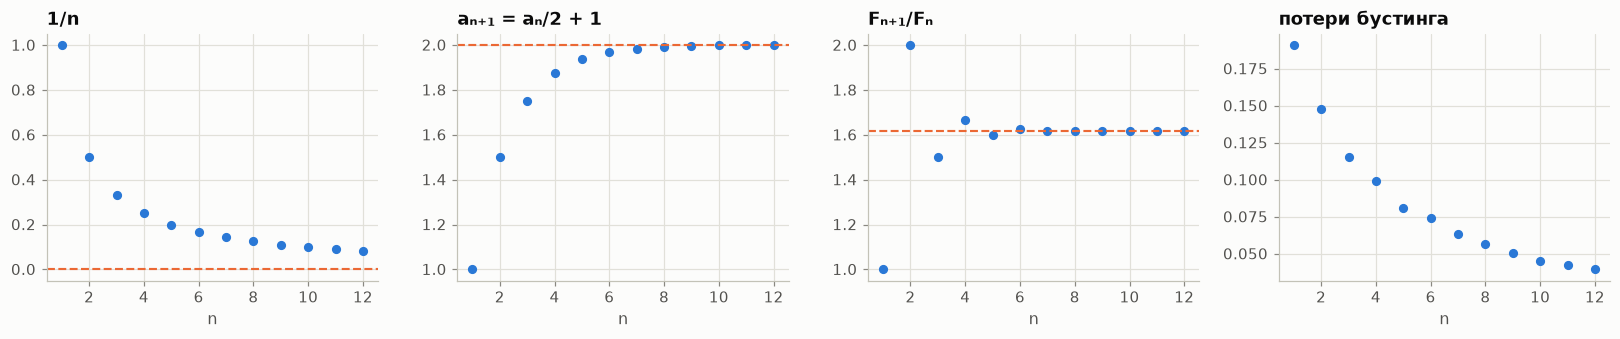

In [3]:
N = 12
formula = [1 / n for n in range(1, N + 1)]
rec = [1.0]
while len(rec) < N:
    rec.append(rec[-1] / 2 + 1)
F = [1, 1]
while len(F) < N + 1:
    F.append(F[-1] + F[-2])
fib = [F[n] / F[n - 1] for n in range(1, N + 1)]
X, y = datasets.regression_1d(kind="sine", n=200, noise=0.3, seed=42)
loss = GradientBoosting(n_estimators=30, learning_rate=0.3, max_depth=2).fit(X, y).history_["train"][1:N + 1]

print("рекуррентная:", np.round(rec[:6], 4), "→ 2")
print("Фибоначчи:   ", np.round(fib[:8], 4), "→ φ =", round((1 + 5**0.5) / 2, 6))
print("потери:      ", np.round(loss[:6], 4))

fig, axes = plt.subplots(1, 4, figsize=(15, 3.2))
for ax, (name, a, L) in zip(axes, [("1/n", formula, 0), ("aₙ₊₁ = aₙ/2 + 1", rec, 2),
                                   ("Fₙ₊₁/Fₙ", fib, (1 + 5**0.5) / 2), ("потери бустинга", loss, None)]):
    ax.plot(range(1, N + 1), a, "o", color=BLUE, ms=5)
    if L is not None:
        ax.axhline(L, color=ORANGE, ls="--", lw=1.4)
    ax.set(title=name, xlabel="n")
plt.tight_layout()
plt.show()

### 1.3. Зоопарк поведений

Сходятся (по-разному): $1/n$, $(n-1)/(n+1)$, $(-1)^n/n$, $1 + \sin(n)/n$. Не сходятся: $\sqrt n$, $(-1)^n$,
$(-1)^n n$, $\sin n$.

findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


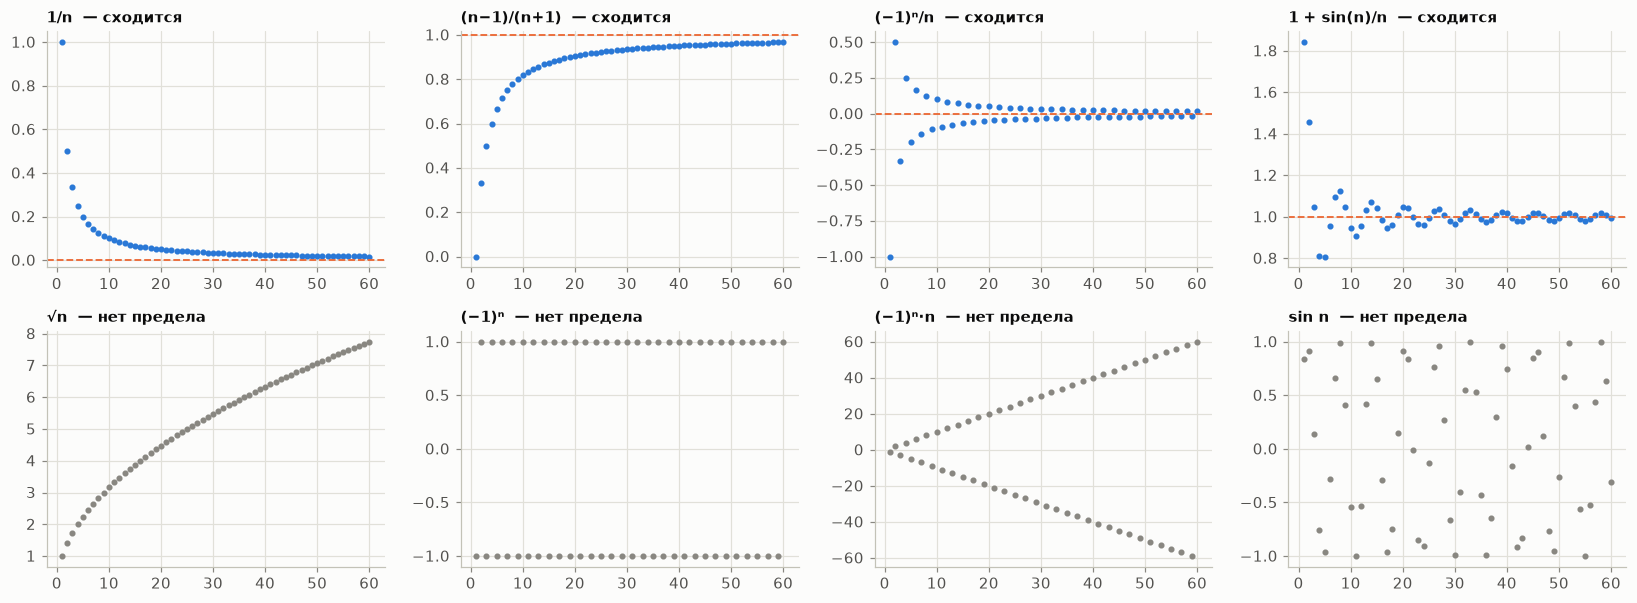

In [4]:
n = np.arange(1, 61)
zoo = [("1/n", 1 / n, 0), ("(n−1)/(n+1)", (n - 1) / (n + 1), 1), ("(−1)ⁿ/n", (-1.0) ** n / n, 0),
       ("1 + sin(n)/n", 1 + np.sin(n) / n, 1), ("√n", np.sqrt(n), None), ("(−1)ⁿ", (-1.0) ** n, None),
       ("(−1)ⁿ·n", (-1.0) ** n * n, None), ("sin n", np.sin(n), None)]
fig, axes = plt.subplots(2, 4, figsize=(15, 5.6))
for ax, (name, a, L) in zip(axes.ravel(), zoo):
    ax.plot(n, a, "o", ms=3, color=BLUE if L is not None else MUTED)
    if L is not None:
        ax.axhline(L, color=ORANGE, ls="--", lw=1.2)
    ax.set_title(name + ("  — сходится" if L is not None else "  — нет предела"), fontsize=10)
plt.tight_layout()
plt.show()

### 1.4. Коридор ε и номер N(ε)

$\lim a_n = L$: для любого ε найдётся $N$, после которого $|a_n - L| < \varepsilon$. Отклонение
считаем по точной формуле (например, $5/(n+3)$ для $(2n+1)/(n+3)$): разность $a_n - L$ в
компьютере на самой границе коридора может округлиться не в ту сторону.

In [5]:
seqs = {
    "1/n → 0": lambda n: 1 / n,
    "(2n+1)/(n+3) → 2": lambda n: 5 / (n + 3),
    "1/n² → 0": lambda n: 1 / n**2,
    "1/2ⁿ → 0": lambda n: 0.5**n,
    "sin(n)/n → 0": lambda n: np.abs(np.sin(n)) / n,
    "(1+1/n)ⁿ → e": lambda n: np.e - (1 + 1 / n) ** n,
}
for name, dev in seqs.items():
    print(f"{name:18}", "  ".join(f"ε={eps}: N={first_N(dev, eps):>5}" for eps in (0.1, 0.01, 0.001)))

1/n → 0            ε=0.1: N=   11  ε=0.01: N=  101  ε=0.001: N= 1001
(2n+1)/(n+3) → 2   ε=0.1: N=   48  ε=0.01: N=  498  ε=0.001: N= 4998
1/n² → 0           ε=0.1: N=    4  ε=0.01: N=   11  ε=0.001: N=   32
1/2ⁿ → 0           ε=0.1: N=    4  ε=0.01: N=    7  ε=0.001: N=   10
sin(n)/n → 0       ε=0.1: N=    9  ε=0.01: N=  100  ε=0.001: N=  989
(1+1/n)ⁿ → e       ε=0.1: N=   13  ε=0.01: N=  135  ε=0.001: N= 1359


Анимация: коридор сужается — номер $N$ растёт, но всегда находится.

In [6]:
n = np.arange(1, 101)
a = 1 / n
eps_list = [0.3, 0.2, 0.1, 0.06, 0.04, 0.025, 0.015, 0.01]
fig, ax = plt.subplots(figsize=(7, 3.6), dpi=72)


def frame(i):
    ax.clear()
    eps = eps_list[i]
    inside = a < eps
    N = first_N(lambda m: 1 / m, eps, 1000)
    ax.axhspan(-eps, eps, color=ORANGE, alpha=0.15)
    ax.plot(n[inside], a[inside], "o", color=BLUE, ms=4)
    ax.plot(n[~inside], a[~inside], "o", color=RED, ms=4)
    ax.axvline(N, color="gray", ls="--")
    ax.set(ylim=(-0.4, 1.05), xlabel="n", ylabel="1/n", title=f"ε = {eps}: все члены с N = {N} внутри")
    return []


anim = animation.FuncAnimation(fig, frame, frames=len(eps_list), interval=900)
plt.close(fig)
display(HTML(anim.to_jshtml()))

### 1.5. Доказательства по ε–N: формула против перебора

Из неравенств получили формулы: $N = \lfloor 1/\varepsilon \rfloor + 1$ для $1/n$,
$N = \lfloor 5/\varepsilon - 3 \rfloor + 1$ для $(2n+1)/(n+3)$, $N = \lfloor \log_2(1/\varepsilon) \rfloor + 1$
для $1/2^n$. Проверим перебором. А для $n/(n^2+1)$ огрубление $\frac{n}{n^2+1} < \frac1n$ даёт формулу
с запасом — она не меньше наименьшего $N$.

In [7]:
formulas = {
    "1/n": (lambda n: 1 / n, lambda e: math.floor(1 / e) + 1),
    "(2n+1)/(n+3)": (lambda n: 5 / (n + 3), lambda e: max(1, math.floor(5 / e - 3) + 1)),
    "1/2ⁿ": (lambda n: 0.5**n, lambda e: math.floor(math.log2(1 / e)) + 1),
}
for name, (dev, Nf) in formulas.items():
    for eps in (0.3, 0.07, 0.01, 0.002):
        assert first_N(dev, eps) == Nf(eps), (name, eps)
    print(f"{name:13} формула совпала с перебором при ε = 0.3, 0.07, 0.01, 0.002")
for eps in (0.1, 0.01):
    print(f"n/(n²+1), ε = {eps}: наименьшее N = {first_N(lambda n: n / (n**2 + 1), eps)}, огрублённая формула {math.floor(1 / eps) + 1}")

1/n           формула совпала с перебором при ε = 0.3, 0.07, 0.01, 0.002
(2n+1)/(n+3)  формула совпала с перебором при ε = 0.3, 0.07, 0.01, 0.002
1/2ⁿ          формула совпала с перебором при ε = 0.3, 0.07, 0.01, 0.002
n/(n²+1), ε = 0.1: наименьшее N = 10, огрублённая формула 11
n/(n²+1), ε = 0.01: наименьшее N = 100, огрублённая формула 101


### 1.6. Геометрическая прогрессия и остаток бустинга

$q^n \to 0$ при $|q| < 1$; номер для коридора ε — $n > \ln\varepsilon / \ln|q|$. Остаток прогноза
$F_m = F_{m-1} + \nu(y - F_{m-1})$ равен $(1 - \nu)^m (y - F_0)$.

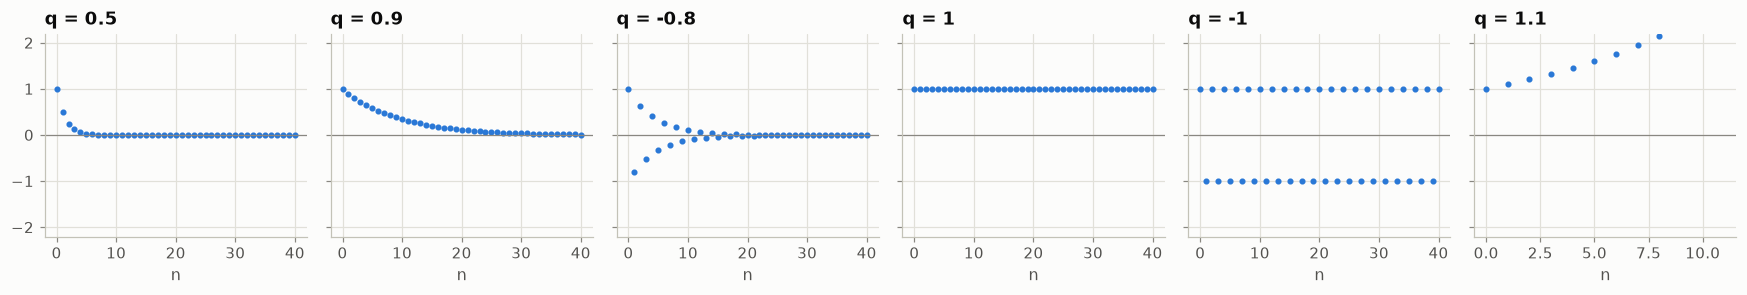

q = 0.5: для ε = 0.01 нужно n > 6.64
q = 0.9: для ε = 0.01 нужно n > 43.71
ν = 0.1, шаг 10: F = 6.5132, остаток 34.87% от y
ν = 0.1, шаг 22: F = 9.0152, остаток 9.85% от y
ν = 0.1, шаг 44: F = 9.9030, остаток 0.97% от y


In [8]:
n = np.arange(0, 41)
fig, axes = plt.subplots(1, 6, figsize=(16, 2.8), sharey=True)
for ax, q in zip(axes, [0.5, 0.9, -0.8, 1, -1, 1.1]):
    v = q**n.astype(float)
    ax.plot(n, np.where(np.abs(v) < 3, v, np.nan), "o", ms=3, color=BLUE)
    ax.axhline(0, color=MUTED, lw=0.8)
    ax.set(title=f"q = {q}", ylim=(-2.2, 2.2), xlabel="n")
plt.tight_layout()
plt.show()

for q in (0.5, 0.9):
    print(f"q = {q}: для ε = 0.01 нужно n > {math.log(0.01) / math.log(q):.2f}")
y_t, F_t, nu = 10.0, 0.0, 0.1
for m in range(1, 45):
    F_t += nu * (y_t - F_t)
    if m in (10, 22, 44):
        print(f"ν = 0.1, шаг {m}: F = {F_t:.4f}, остаток {(y_t - F_t) / y_t:.2%} от y")
assert 0.9**21 > 0.1 > 0.9**22 and 0.9**43 > 0.01 > 0.9**44

### 1.7. Скорость сходимости

Сколько членов нужно, чтобы войти в коридор $10^{-6}$: $1/\sqrt n$ — $10^{12} + 1$, $1/n$ — $10^6 + 1$,
$1/n^2$ — 1001, $1/2^n$ — 20, $1/n!$ — 10. На логарифмической шкале $q^n$ — прямая (линейная сходимость).

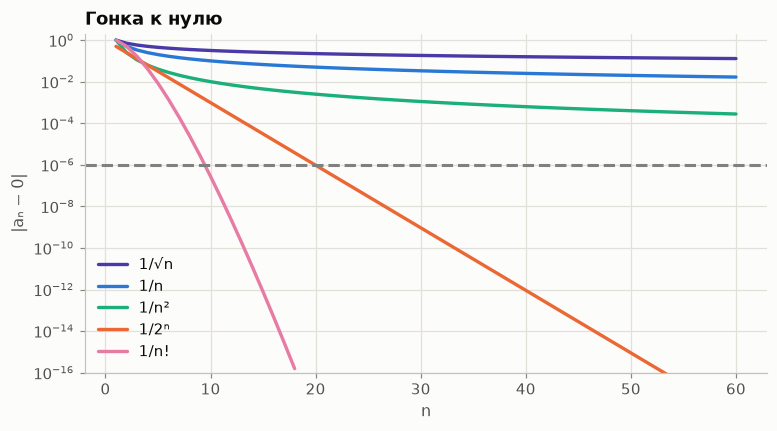

N(1e-6): 1/n² → 1001  1/2ⁿ → 20  1/n! → 10


In [9]:
n = np.arange(1, 61)
fig, ax = plt.subplots(figsize=(8, 4))
for (name, v), col in zip([("1/√n", 1 / np.sqrt(n)), ("1/n", 1 / n), ("1/n²", 1 / n**2), ("1/2ⁿ", 0.5**n),
                           ("1/n!", np.array([1 / math.factorial(int(k)) for k in n]))],
                          [VIOLET, BLUE, AQUA, ORANGE, MAGENTA]):
    ax.semilogy(n, np.where(v > 1e-17, v, np.nan), lw=2.2, color=col, label=name)
ax.axhline(1e-6, color="gray", ls="--")
ax.set(xlabel="n", ylabel="|aₙ − 0|", ylim=(1e-16, 2), title="Гонка к нулю")
ax.legend()
plt.show()
print("N(1e-6): 1/n² →", first_N(lambda k: 1 / k**2, 1e-6), " 1/2ⁿ →", first_N(lambda k: 0.5**k, 1e-6, 100),
      " 1/n! →", next(k for k in range(1, 30) if 1 / math.factorial(k) < 1e-6))

### 1.8. Монотонная и ограниченная — значит, сходится

$(1 + 1/n)^n$ растёт и меньше 3 — предел $e$ существует. $1 + 1/1! + \dots + 1/n!$ сходится к тому же $e$
намного быстрее. Гармонические суммы растут без потолка.

In [10]:
n = np.arange(1, 100001, dtype=float)
a = (1 + 1 / n) ** n
print("растёт:", bool(np.all(np.diff(a) > -1e-12)), "  максимум:", a.max(), "< 3:", a.max() < 3)
b, f = 1.0, 1
for k in range(1, 11):
    f *= k
    b += 1 / f
print(f"a_1000 = {(1 + 1 / 1000)**1000:.7f}, b_10 = {b:.10f}, e = {math.e:.10f}")
H, k = 0.0, 0
while H <= 10:
    k += 1
    H += 1 / k
print("гармоническая сумма превышает 10 на слагаемом", k)

растёт: True   максимум: 2.7182682371922975 < 3: True
a_1000 = 2.7169239, b_10 = 2.7182818011, e = 2.7182818285
гармоническая сумма превышает 10 на слагаемом 12367


### 1.9. Итерации $a_{n+1} = g(a_n)$: лестница Ламерея

Если предел есть и $g$ непрерывна, то $L = g(L)$. Но решение уравнения — лишь кандидат.

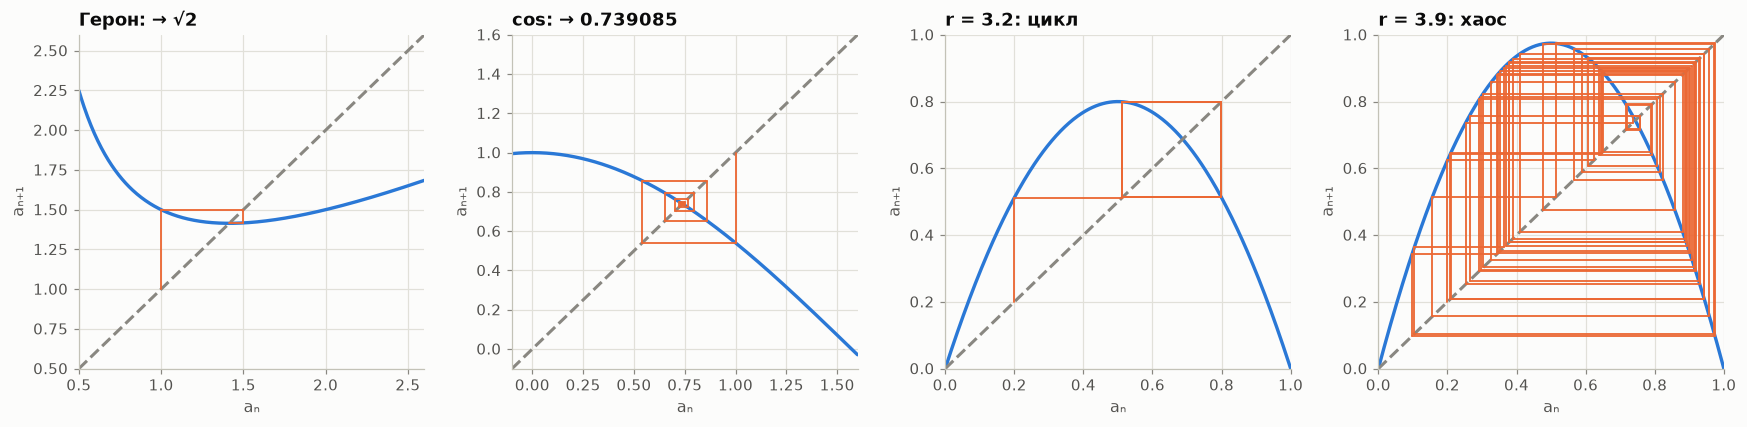

Герон, шаг 1: 1.500000000000000, ошибка 8.6e-02
Герон, шаг 2: 1.416666666666667, ошибка 2.5e-03
Герон, шаг 3: 1.414215686274510, ошибка 2.1e-06
Герон, шаг 4: 1.414213562374690, ошибка 1.6e-12
Герон, шаг 5: 1.414213562373095, ошибка 2.2e-16
cos: шесть верных знаков после 34 шагов
r = 3.2, хвост: [0.513, 0.7995, 0.513, 0.7995]  а L = g(L) даёт 0.6875


In [11]:
def cobweb(ax, g, a0, steps, dom, title):
    x = np.linspace(*dom, 400)
    ax.plot(x, g(x), color=BLUE, lw=2.2)
    ax.plot(dom, dom, color=MUTED, ls="--")
    a = a0
    for _ in range(steps):
        b = g(a)
        ax.plot([a, a], [a, b], color=ORANGE, lw=1.2)
        ax.plot([a, b], [b, b], color=ORANGE, lw=1.2)
        a = b
    ax.set(xlim=dom, ylim=dom, title=title, xlabel="aₙ", ylabel="aₙ₊₁")


fig, axes = plt.subplots(1, 4, figsize=(16, 4))
cobweb(axes[0], lambda a: (a + 2 / a) / 2, 1.0, 6, (0.5, 2.6), "Герон: → √2")
cobweb(axes[1], np.cos, 1.0, 30, (-0.1, 1.6), "cos: → 0.739085")
cobweb(axes[2], lambda a: 3.2 * a * (1 - a), 0.2, 60, (0, 1), "r = 3.2: цикл")
cobweb(axes[3], lambda a: 3.9 * a * (1 - a), 0.2, 60, (0, 1), "r = 3.9: хаос")
plt.tight_layout()
plt.show()

a = 1.0
for i in range(5):
    a = (a + 2 / a) / 2
    print(f"Герон, шаг {i + 1}: {a:.15f}, ошибка {abs(a - math.sqrt(2)):.1e}")
a, k = 1.0, 0
while abs(a - 0.7390851332151607) >= 0.5e-6:
    a, k = math.cos(a), k + 1
print("cos: шесть верных знаков после", k, "шагов")
x = 0.2
for _ in range(1000):
    x = 3.2 * x * (1 - x)
print("r = 3.2, хвост:", [round(x := 3.2 * x * (1 - x), 4) for _ in range(4)], " а L = g(L) даёт", 1 - 1 / 3.2)

### 1.10. Ряды: сумма — предел частичных сумм

½ + ¼ + …          S_10 = 0.999023, S_1000 = 1.000000, S_100000 = 1.000000
1 + 1/4 + 1/9 + …  S_10 = 1.549768, S_1000 = 1.643935, S_100000 = 1.644924
1 + 1/2 + 1/3 + …  S_10 = 2.928968, S_1000 = 7.485471, S_100000 = 12.090146
1 − 1/2 + 1/3 − …  S_10 = 0.645635, S_1000 = 0.692647, S_100000 = 0.693142


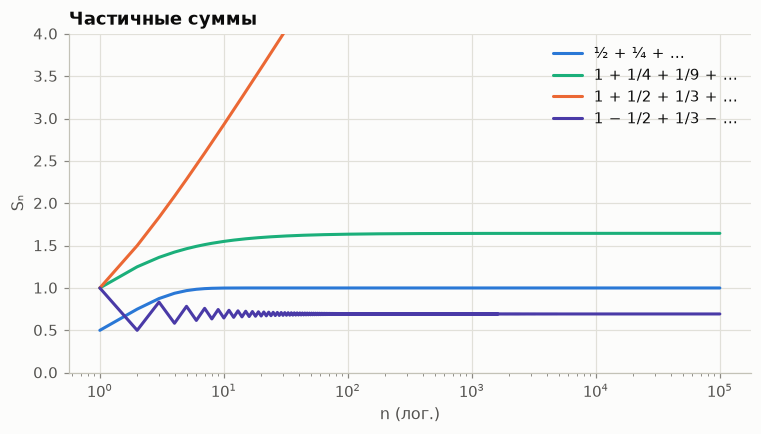

π²/6 = 1.6449340668482264  ln 2 = 0.6931471805599453
0.999… = 0.9/(1 − 0.1) = 1.0


In [12]:
k = np.arange(1, 100001, dtype=float)
series = {"½ + ¼ + …": 0.5**k, "1 + 1/4 + 1/9 + …": 1 / k**2, "1 + 1/2 + 1/3 + …": 1 / k,
          "1 − 1/2 + 1/3 − …": (-1.0) ** (k + 1) / k}
fig, ax = plt.subplots(figsize=(8, 4))
for (name, t), col in zip(series.items(), [BLUE, AQUA, ORANGE, VIOLET]):
    S = np.cumsum(t)
    ax.semilogx(k, S, lw=2, color=col, label=name)
    print(f"{name:18} S_10 = {S[9]:.6f}, S_1000 = {S[999]:.6f}, S_100000 = {S[-1]:.6f}")
ax.set(xlabel="n (лог.)", ylabel="Sₙ", ylim=(0, 4), title="Частичные суммы")
ax.legend()
plt.show()
print("π²/6 =", math.pi**2 / 6, " ln 2 =", math.log(2))
q = 0.1
print("0.999… = 0.9/(1 − 0.1) =", 0.9 / (1 - q))

## Блок 2. Предел функции в точке

### 2.1. Таблица, график, алгебра — и ловушка таблицы

(x²−1)/(x−1), a=1 → 2    [1.99  1.999 2.001 2.01 ]
(x³−1)/(x−1), a=1 → 3    [2.9701   2.997001 3.003001 3.0301  ]
(√x−1)/(x−1), a=1 → ½    [0.501256 0.500125 0.499875 0.498756]
sin x / x,   a=0 → 1     [0.999983 1.       1.       0.999983]
(eˣ−1)/x,    a=0 → 1     [0.995017 0.9995   1.0005   1.005017]
sin(π/x) в 0.1, 0.01, 0.001: ['-1.2e-15', '2.0e-15', '-3.2e-13']  — а в 2/(4k+1): [np.float64(1.0), np.float64(1.0), np.float64(1.0)]


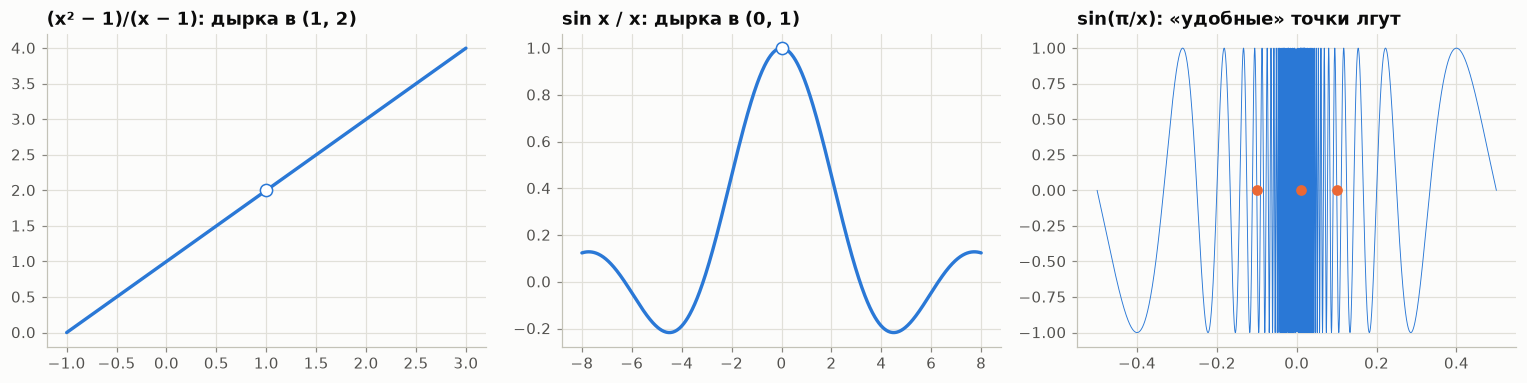

In [13]:
tests = {
    "(x²−1)/(x−1), a=1 → 2": (lambda x: (x**2 - 1) / (x - 1), 1, 2),
    "(x³−1)/(x−1), a=1 → 3": (lambda x: (x**3 - 1) / (x - 1), 1, 3),
    "(√x−1)/(x−1), a=1 → ½": (lambda x: (np.sqrt(x) - 1) / (x - 1), 1, 0.5),
    "sin x / x,   a=0 → 1": (lambda x: np.sin(x) / x, 0, 1),
    "(eˣ−1)/x,    a=0 → 1": (lambda x: (np.exp(x) - 1) / x, 0, 1),
}
for name, (f, a, L) in tests.items():
    vals = [f(a + d) for d in (-0.01, -0.001, 0.001, 0.01)]
    print(f"{name:24}", np.round(vals, 6))
    assert all(abs(v - L) < 0.04 for v in vals)

g = lambda x: np.sin(np.pi / x)  # noqa: E731
print("sin(π/x) в 0.1, 0.01, 0.001:", [f"{g(x):.1e}" for x in (0.1, 0.01, 0.001)], " — а в 2/(4k+1):",
      [round(g(2 / (4 * k + 1)), 6) for k in (10, 100, 1000)])

fig, axes = plt.subplots(1, 3, figsize=(14, 3.6))
x = np.linspace(-1, 3, 400)
axes[0].plot(x, x + 1, color=BLUE, lw=2.2)
axes[0].plot([1], [2], "o", mfc="white", mec=BLUE, ms=8)
axes[0].set_title("(x² − 1)/(x − 1): дырка в (1, 2)")
xs = np.linspace(-8, 8, 801)
xs = xs[xs != 0]
axes[1].plot(xs, np.sin(xs) / xs, color=BLUE, lw=2.2)
axes[1].plot([0], [1], "o", mfc="white", mec=BLUE, ms=8)
axes[1].set_title("sin x / x: дырка в (0, 1)")
xt = np.linspace(-0.5, 0.5, 20001)
xt = xt[xt != 0]
axes[2].plot(xt, g(xt), color=BLUE, lw=0.6)
axes[2].plot([0.1, 0.01, -0.1], [0, 0, 0], "o", color=ORANGE, ms=6)
axes[2].set_title("sin(π/x): «удобные» точки лгут")
plt.tight_layout()
plt.show()

### 2.2. По Гейне: две последовательности — два ответа

In [14]:
k = np.arange(1, 8)
f = lambda x: np.sin(1 / x)  # noqa: E731
print("xₙ = 1/(πn):       f =", np.round(f(1 / (np.pi * k)), 12))
print("xₙ = 1/(2πn + π/2): f =", np.round(f(1 / (2 * np.pi * k + np.pi / 2)), 12))
xs1, xs2 = 1 / (np.pi * k), 1 / (2 * np.pi * k + np.pi / 2)
print("x·sin(1/x) на тех же: ", np.round(xs1 * f(xs1), 6), np.round(xs2 * f(xs2), 4), "— оба → 0")

xₙ = 1/(πn):       f = [ 0. -0.  0. -0.  0. -0.  0.]
xₙ = 1/(2πn + π/2): f = [1. 1. 1. 1. 1. 1. 1.]
x·sin(1/x) на тех же:  [ 0. -0.  0. -0.  0. -0.  0.] [0.1273 0.0707 0.049  0.0374 0.0303 0.0255 0.022 ] — оба → 0


### 2.3. Односторонние пределы и «микроскоп»

In [15]:
one = {
    "ступенька [x ≥ 0], 0": (lambda x: (x >= 0) * 1.0, 0),
    "|x|/x, 0": (lambda x: np.abs(x) / x, 0),
    "⌊x⌋, 2": (np.floor, 2),
    "e^(1/x), 0": (lambda x: np.exp(1 / x), 0),
}
with np.errstate(over="ignore"):  # e^(1/x) справа переполняется — это и есть уход в +∞
    for name, (f, a) in one.items():
        print(f"{name:22} слева {f(a - 1e-3):10.4g}   справа {f(a + 1e-3):10.4g}")
for w in [0.5, 0.05, 0.005, 0.0005]:
    x = np.linspace(-w, w, 200001)
    x = x[x != 0]
    r1 = np.ptp(np.sin(1 / x))
    r2 = np.ptp(x * np.sin(1 / x))
    print(f"окно ±{w}: размах sin(1/x) = {r1:.4f}, размах x·sin(1/x) = {r2:.6f}")

ступенька [x ≥ 0], 0   слева          0   справа          1
|x|/x, 0               слева         -1   справа          1
⌊x⌋, 2                 слева          1   справа          2
e^(1/x), 0             слева          0   справа        inf
окно ±0.5: размах sin(1/x) = 2.0000, размах x·sin(1/x) = 0.671882
окно ±0.05: размах sin(1/x) = 2.0000, размах x·sin(1/x) = 0.091509
окно ±0.005: размах sin(1/x) = 2.0000, размах x·sin(1/x) = 0.009795
окно ±0.0005: размах sin(1/x) = 2.0000, размах x·sin(1/x) = 0.000998


## Блок 3. Бесконечность

### 3.1. Бесконечные пределы и log-loss

In [16]:
for M in [100, 10**6]:
    d = 1 / math.sqrt(M)
    print(f"1/x² > {M} при |x| < δ = {d}; проверка: 1/(0.999δ)² = {1 / (0.999 * d)**2:.1f}")
for p in [0.5, 0.1, 0.01, 1e-6, 1e-15]:
    print(f"−ln p при p = {p:g}: {-math.log(p):.3f}")

1/x² > 100 при |x| < δ = 0.1; проверка: 1/(0.999δ)² = 100.2
1/x² > 1000000 при |x| < δ = 0.001; проверка: 1/(0.999δ)² = 1002003.0
−ln p при p = 0.5: 0.693
−ln p при p = 0.1: 2.303
−ln p при p = 0.01: 4.605
−ln p при p = 1e-06: 13.816
−ln p при p = 1e-15: 34.539


### 3.2. Пределы на бесконечности и главные слагаемые

In [17]:
for x in [10, 100, 1000, 10**6]:
    r1 = (2 * x + 1) / (x + 3)
    r2 = (3 * x**2 + x) / (x**2 + 1)
    r3 = (x**2 + 5 * x) / (2 * x**3 + 1)
    print(f"x = {x:>7}: (2x+1)/(x+3) = {r1:.6f}  (3x²+x)/(x²+1) = {r2:.6f}  (x²+5x)/(2x³+1) = {r3:.2e}"
          f"   доля 2x в числителе {2 * x / (2 * x + 1):.4%}")
print("|f − 2| < 0.01 при x >", 5 / 0.01 - 3)
sig = lambda x: 1 / (1 + np.exp(-x))  # noqa: E731
print("σ(5) =", sig(5.0), " σ(10) =", sig(10.0))

x =      10: (2x+1)/(x+3) = 1.615385  (3x²+x)/(x²+1) = 3.069307  (x²+5x)/(2x³+1) = 7.50e-02   доля 2x в числителе 95.2381%
x =     100: (2x+1)/(x+3) = 1.951456  (3x²+x)/(x²+1) = 3.009699  (x²+5x)/(2x³+1) = 5.25e-03   доля 2x в числителе 99.5025%
x =    1000: (2x+1)/(x+3) = 1.995015  (3x²+x)/(x²+1) = 3.000997  (x²+5x)/(2x³+1) = 5.02e-04   доля 2x в числителе 99.9500%
x = 1000000: (2x+1)/(x+3) = 1.999995  (3x²+x)/(x²+1) = 3.000001  (x²+5x)/(2x³+1) = 5.00e-07   доля 2x в числителе 100.0000%
|f − 2| < 0.01 при x > 497.0
σ(5) = 0.9933071490757153  σ(10) = 0.9999546021312976


### 3.3. Асимптоты $(x^2 + 1)/(x - 1)$: вертикальная $x = 1$, наклонная $y = x + 1$

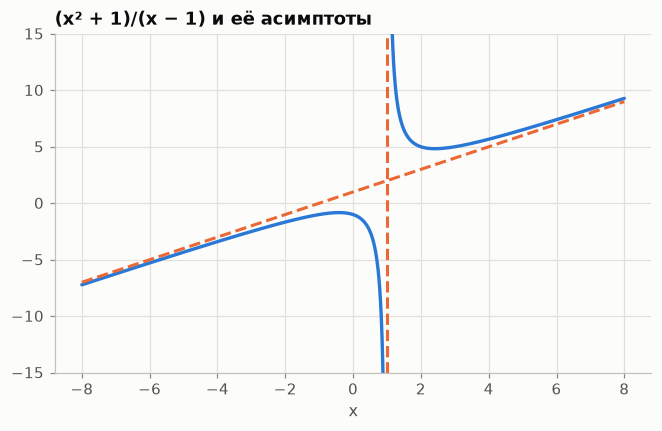

x = 10: f(x) − (x + 1) = 0.222222 = 2/(x − 1) = 0.222222
x = 100: f(x) − (x + 1) = 0.020202 = 2/(x − 1) = 0.020202
x = 1000: f(x) − (x + 1) = 0.002002 = 2/(x − 1) = 0.002002


In [18]:
x = np.linspace(-8, 8, 2001)
x = x[np.abs(x - 1) > 0.02]
y = (x**2 + 1) / (x - 1)
y[np.abs(y) > 30] = np.nan
y[np.r_[False, np.diff(np.sign(x - 1)) != 0]] = np.nan
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(x, y, color=BLUE, lw=2.2)
ax.axvline(1, color=ORANGE, ls="--")
ax.plot(x, x + 1, color=ORANGE, ls="--")
ax.set(ylim=(-15, 15), title="(x² + 1)/(x − 1) и её асимптоты", xlabel="x")
plt.show()
for X in [10, 100, 1000]:
    print(f"x = {X}: f(x) − (x + 1) = {(X**2 + 1) / (X - 1) - (X + 1):.6f} = 2/(x − 1) = {2 / (X - 1):.6f}")

## Блок 4. Строгость: ε–δ

Наибольшее δ ищем перебором (по сетке) и сравниваем с формулами из доказательств:
$\delta = \varepsilon/3$ для $3x - 1$, $\min(1, \varepsilon/5)$ для $x^2$, $\min(1, 2\varepsilon)$ для $1/x$,
$\min(4, 2\varepsilon)$ для $\sqrt x$. Формула гарантирует победу, но не обязана быть наибольшей.

3x − 1 → 5 (x → 2)   ε = 0.01: δ* = 0.00333, формула 0.00333
x² → 4 (x → 2)       ε = 0.01: δ* = 0.00250, формула 0.00200


1/x → 1/2 (x → 2)    ε = 0.01: δ* = 0.03922, формула 0.02000

√x → 2 (x → 4)       ε = 0.01: δ* = 0.03990, формула 0.02000


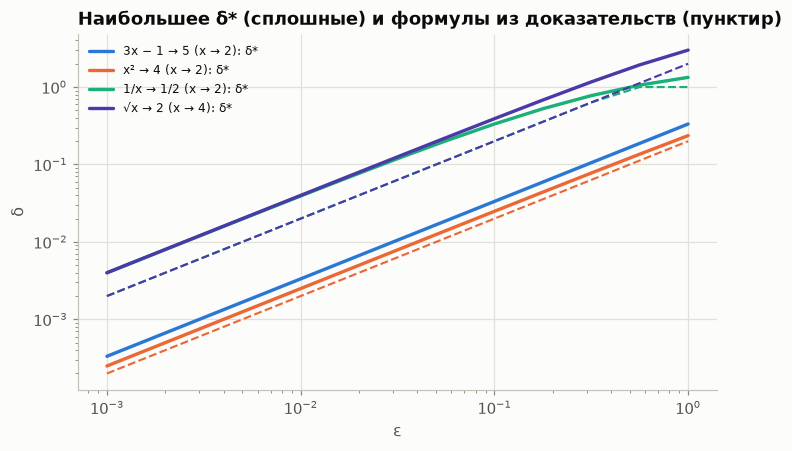

ступенька, L = 0.5, ε = 0.4: None — подходящего δ нет


In [19]:
def best_delta(f, a, L, eps, d_max=4.0):
    """Наибольшее δ ≤ d_max, при котором |f(x) − L| < ε для всех 0 < |x − a| < δ (проверка по сетке)."""
    def ok(d):
        x = np.linspace(a - d, a + d, 20001)
        x = x[x != a]
        with np.errstate(all="ignore"):
            return bool(np.all(np.abs(f(x) - L) < eps))
    if ok(d_max):
        return d_max
    if not ok(1e-9):
        return None  # даже крошечная окрестность не помогает: L — не предел
    lo, hi = 0.0, d_max
    for _ in range(50):
        mid = (lo + hi) / 2
        lo, hi = (mid, hi) if ok(mid) else (lo, mid)
    return lo


tasks = {
    "3x − 1 → 5 (x → 2)": (lambda x: 3 * x - 1, 2, 5, lambda e: e / 3),
    "x² → 4 (x → 2)": (lambda x: x**2, 2, 4, lambda e: min(1, e / 5)),
    "1/x → 1/2 (x → 2)": (lambda x: 1 / x, 2, 0.5, lambda e: min(1, 2 * e)),
    "√x → 2 (x → 4)": (lambda x: np.sqrt(x), 4, 2, lambda e: min(4, 2 * e)),
}
eps_grid = np.logspace(-3, 0, 13)
fig, ax = plt.subplots(figsize=(7.5, 4.2))
for (name, (f, a, L, form)), col in zip(tasks.items(), [BLUE, ORANGE, AQUA, VIOLET]):
    best = np.array([best_delta(f, a, L, e) for e in eps_grid])
    formula = np.array([form(e) for e in eps_grid])
    assert np.all(formula <= best * (1 + 1e-6)), name
    ax.loglog(eps_grid, best, color=col, lw=2.2, label=name + ": δ*")
    ax.loglog(eps_grid, formula, color=col, lw=1.4, ls="--")
    print(f"{name:20} ε = 0.01: δ* = {best_delta(f, a, L, 0.01):.5f}, формула {form(0.01):.5f}")
ax.set(xlabel="ε", ylabel="δ", title="Наибольшее δ* (сплошные) и формулы из доказательств (пунктир)")
ax.legend(fontsize=8)
plt.show()
print("ступенька, L = 0.5, ε = 0.4:", best_delta(lambda x: (x >= 0) * 1.0, 0, 0.5, 0.4), "— подходящего δ нет")

## Блок 5. Пределы в анализе и ML

### 5.1. Производная как предел

In [20]:
s = lambda t: 3 * t**2 - t**3 / 5  # noqa: E731
for h in [0.1, 0.01, 0.001, -0.001, -0.1]:
    print(f"h = {h:>6}: (s(2 + h) − s(2))/h = {(s(2 + h) - s(2)) / h:.7f}   9.6 + 1.8h − 0.2h² = {9.6 + 1.8 * h - 0.2 * h**2:.7f}")
for h in [0.01, -0.01]:
    print(f"|x| в нуле, h = {h}: {abs(h) / h:+.0f};  ∛x в нуле: {np.cbrt(h) / h:.2f}")

h =    0.1: (s(2 + h) − s(2))/h = 9.7780000   9.6 + 1.8h − 0.2h² = 9.7780000
h =   0.01: (s(2 + h) − s(2))/h = 9.6179800   9.6 + 1.8h − 0.2h² = 9.6179800
h =  0.001: (s(2 + h) − s(2))/h = 9.6017998   9.6 + 1.8h − 0.2h² = 9.6017998
h = -0.001: (s(2 + h) − s(2))/h = 9.5981998   9.6 + 1.8h − 0.2h² = 9.5981998
h =   -0.1: (s(2 + h) − s(2))/h = 9.4180000   9.6 + 1.8h − 0.2h² = 9.4180000
|x| в нуле, h = 0.01: +1;  ∛x в нуле: 21.54
|x| в нуле, h = -0.01: -1;  ∛x в нуле: 21.54


### 5.2. Бустинг: потери на обучении — монотонная ограниченная последовательность

ν = 0.1: обучение 0.2101 → 0.00467 (Δ последнего дерева -1.93e-05); проверка: минимум 0.0794 при M = 139, в конце 0.0900


ν = 0.3: обучение 0.1615 → 0.00010 (Δ последнего дерева -5.92e-07); проверка: минимум 0.0772 при M = 36, в конце 0.1112


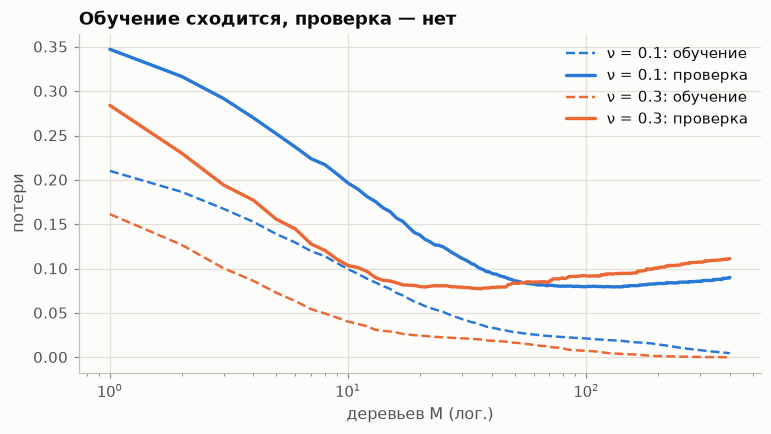

In [21]:
X, y = datasets.regression_1d(kind="sine", n=200, noise=0.3, seed=42)
Xtr, Xva, ytr, yva = datasets.train_test_split(X, y, test_size=0.3, seed=0)
fig, ax = plt.subplots(figsize=(8, 4))
for nu, col in [(0.1, BLUE), (0.3, ORANGE)]:
    m = GradientBoosting(n_estimators=400, learning_rate=nu, max_depth=2).fit(Xtr, ytr, eval_set=(Xva, yva))
    tr, va = np.array(m.history_["train"]), np.array(m.history_["eval"])
    assert np.all(np.diff(tr) <= 1e-12) and tr.min() >= 0
    best = int(va.argmin())
    assert va[-1] > va[best]
    print(f"ν = {nu}: обучение {tr[1]:.4f} → {tr[-1]:.5f} (Δ последнего дерева {tr[-1] - tr[-2]:.2e}); "
          f"проверка: минимум {va[best]:.4f} при M = {best}, в конце {va[-1]:.4f}")
    ax.semilogx(np.arange(1, 401), tr[1:], color=col, lw=1.6, ls="--", label=f"ν = {nu}: обучение")
    ax.semilogx(np.arange(1, 401), va[1:], color=col, lw=2.2, label=f"ν = {nu}: проверка")
ax.set(xlabel="деревьев M (лог.)", ylabel="потери", title="Обучение сходится, проверка — нет")
ax.legend()
plt.show()

### 5.3. Сигмоида и log-loss на краях

In [22]:
for F in [-10.0, 10.0]:
    print(f"F = {F}: σ(F) = {1 / (1 + math.exp(-F)):.7f}, потери при y = 1: {math.log1p(math.exp(-F)) if F > 0 else -F + math.log1p(math.exp(F)):.7f}")
lo, hi = 30.0, 40.0
for _ in range(60):
    mid = (lo + hi) / 2
    lo, hi = (lo, mid) if 1 / (1 + math.exp(-mid)) == 1.0 else (mid, hi)
print(f"σ(F) == 1.0 в float64 начиная с F ≈ {hi:.2f}")

F = -10.0: σ(F) = 0.0000454, потери при y = 1: 10.0000454
F = 10.0: σ(F) = 0.9999546, потери при y = 1: 0.0000454
σ(F) == 1.0 в float64 начиная с F ≈ 36.74


### 5.4. Закон больших чисел: среднее бросков кубика → 3.5

Тот же генератор Mulberry32, что в браузере (`GBC.RNG`): при одном seed траектории совпадают.

эксперимент 1:

 n = 10: 3.4000, n = 100: 3.5100, n = 1000: 3.4270, n = 10000: 3.4678, n = 100000: 3.4870


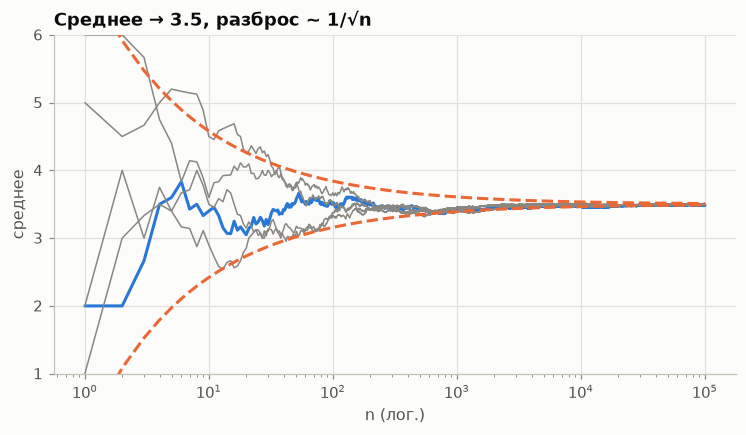

σ одного броска = 1.7078;  ±2σ/√n при n = 100: ±0.342, при n = 10 000: ±0.0342


In [23]:
fig, ax = plt.subplots(figsize=(8, 4))
nn = np.arange(1, 100001)
for t in range(5):
    rng = Mulberry32(100 + t)
    rolls = np.array([rng.randint(6) + 1 for _ in range(100000)])
    mean = np.cumsum(rolls) / nn
    ax.semilogx(nn, mean, lw=2 if t == 0 else 1, color=BLUE if t == 0 else MUTED)
    if t == 0:
        print("эксперимент 1:", ", ".join(f"n = {k}: {mean[k - 1]:.4f}" for k in (10, 100, 1000, 10000, 100000)))
sd = math.sqrt(35 / 12)
ax.semilogx(nn, 3.5 + 2 * sd / np.sqrt(nn), color=ORANGE, ls="--")
ax.semilogx(nn, 3.5 - 2 * sd / np.sqrt(nn), color=ORANGE, ls="--")
ax.set(ylim=(1, 6), xlabel="n (лог.)", ylabel="среднее", title="Среднее → 3.5, разброс ~ 1/√n")
plt.show()
print(f"σ одного броска = {sd:.4f};  ±2σ/√n при n = 100: ±{2 * sd / 10:.3f}, при n = 10 000: ±{2 * sd / 100:.4f}")

### 5.5. Где компьютер ломает пределы — сверка с высокоточной арифметикой

Модуль `decimal` считает с 50 знаками: он показывает, каким должен быть ответ.

In [24]:
getcontext().prec = 50
for n in [10**8, 10**12, 10**15, 10**16]:
    exact = (1 + Decimal(1) / n) ** n
    naive = (1 + 1 / n) ** n
    stable = math.exp(n * math.log1p(1 / n))
    print(f"n = 1e{len(str(n)) - 1}: в лоб {naive:.10f}, устойчиво {stable:.10f}, точно {float(exact):.10f}")
for x in [1e-4, 1e-8]:
    exact = 0.5 - x**2 / 24  # ряд Тейлора: (1 − cos x)/x² = 1/2 − x²/24 + … (урок 15.7)
    print(f"x = {x}: (1 − cos x)/x² в лоб = {(1 - math.cos(x)) / x**2:.10f}, через sin = {2 * math.sin(x / 2)**2 / x**2:.10f}, точно ≈ {exact:.10f}")
print("1 + 1e-16 == 1:", 1 + 1e-16 == 1, "  σ(37) == 1.0:", 1 / (1 + math.exp(-37)) == 1.0)

n = 1e8: в лоб 2.7182817983, устойчиво 2.7182818149, точно 2.7182818149
n = 1e12: в лоб 2.7185234960, устойчиво 2.7182818285, точно 2.7182818285
n = 1e15: в лоб 3.0350352065, устойчиво 2.7182818285, точно 2.7182818285
n = 1e16: в лоб 1.0000000000, устойчиво 2.7182818285, точно 2.7182818285
x = 0.0001: (1 − cos x)/x² в лоб = 0.4999999970, через sin = 0.4999999996, точно ≈ 0.4999999996
x = 1e-08: (1 − cos x)/x² в лоб = 0.0000000000, через sin = 0.5000000000, точно ≈ 0.5000000000
1 + 1e-16 == 1: True   σ(37) == 1.0: True


## Упражнения

Условия — `exercises/tasks.md`, решения — `exercises/solutions.py`.

1. ★☆☆ Пределы дробей с «дыркой».
2. ★☆☆ Номер $N(\varepsilon)$ для $(n+1)/n$ и $(3n-1)/(n+2)$.
3. ★☆☆ Геометрическая прогрессия и остаток бустинга.
4. ★★☆ Предел на бесконечности и главные слагаемые.
5. ★★☆ Односторонние пределы.
6. ★★☆ Асимптоты $\frac{2x^2 - 3}{x + 1}$.
7. ★★☆ Итерация $a_{n+1} = \sqrt{6 + a_n}$.
8. ★★☆ Ряды: геометрический и гармонический.
9. ★★★ Нет предела: $\cos(1/x)$ по Гейне.
10. ★★★ Доказательство по ε–δ для $x^2$ в точке 3.
11. ★★★ Ловушка округления: $(1 - \cos x)/x^2$.